Base model test - ResNet 50

In [ ]:
# Mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Set up dataset path
os.chdir("drive/My Drive/")
spreadsheet_path = "Auslan Static Dataset Breakdown"
dataset_path = "AuslanStaticData"

Mounted at /content/drive


In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

# Sheets access
gc = gspread.authorize(creds)

In [ ]:
import pandas as pd

worksheet = gc.open('Auslan Static Dataset Breakdown').sheet1

# Get all values from the worksheet
rows = worksheet.get_all_values()

# Convert to DataFrame with first row as column names
spreadsheet = pd.DataFrame(rows[1:], columns=rows[0])

print(spreadsheet)

     ID Subject         Date            Device        Filename Class Lighting  \
0     0    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_0_1.jpg     0  Natural   
1     1    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_1_1.jpg     1  Natural   
2     2    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_2_1.jpg     2  Natural   
3     3    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_3_1.jpg     3  Natural   
4     4    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_4_1.jpg     4  Natural   
...  ..     ...          ...               ...             ...   ...      ...   
4729       Nick  Apr 29 2025         iPhone 12  Nick_u_114.JPG     u  Natural   
4730       Nick  Apr 29 2025         iPhone 12  Nick_u_115.JPG     u  Natural   
4731       Nick  Apr 29 2025         iPhone 12  Nick_u_116.JPG     u  Natural   
4732       Nick  Apr 29 2025         iPhone 12  Nick_u_117.JPG     u  Natural   
4733       Nick  Apr 29 2025         iPhone 12  Nick_u_118.JPG     u  Natural   

     Light level           

In [ ]:
# Get list of files
file_list = os.listdir(dataset_path)

# Convert to DataFrame
drive_files = pd.DataFrame(file_list, columns=['Filename'])

set1 = set(drive_files['Filename'])
set2 = set(spreadsheet["Filename"])

# Find missing files
missing_in_df2 = set1 - set2  # Files in df1 but not in df2
missing_in_df1 = set2 - set1  # Files in df2 but not in df1

print("Files missing in Spreadsheet:", missing_in_df2)
print("Files missing in Drive folder:", missing_in_df1)

print(set1)
print(set2)

Files missing in Spreadsheet: set()
Files missing in Drive folder: set()
{'Nick_6_92.jpg', 'Luke_1_34.jpg', 'Nick_2_104.jpg', 'Nick_o_56.jpg', 'Nick_8_67.jpg', 'Nick_3_18.jpg', 'Nick_u_72.JPG', 'Evelyn_g_1.jpg', 'Daniel_1_40.jpg', 'Luke_0_31.jpg', 'Luke_0_20.jpg', 'Luke_o_7.jpg', 'Luke_u_32.jpg', 'Daniel_3_43.jpg', 'Nick_0_14.jpg', 'Luke_a_31.jpg', 'Nick_i_116.JPG', 'Luke_u_41.JPG', 'Nick_7_79.jpg', 'Nick_2_7.jpg', 'Daniel_7_2.jpg', 'Nick_e_7.jpg', 'Luke_0_22.jpg', 'Nick_8_13.jpg', 'Evelyn_x_6.jpg', 'Nick_0_29.jpg', 'Evelyn_i_28.jpg', 'Nick_2_89.jpg', 'Evelyn_3_26.jpg', 'Nick_o_6.jpg', 'Luke_u_9.jpg', 'Luke_8_34.jpg', 'Nick_i_32.jpg', 'Nick_9_23.jpg', 'Evelyn_9_44.jpeg', 'Nick_2_49.jpg', 'Daniel_8_41.jpg', 'Daniel_1_12.jpg', 'Nick_5_100.jpg', 'Nick_9_105.jpg', 'Nick_3_113.JPG', 'Daniel_4_29.jpg', 'Nick_e_17.jpg', 'Nick_c_3.jpg', 'Nick_g_3.jpg', 'Evelyn_m_4.jpg', 'Evelyn_6_11.jpg', 'Evelyn_i_3.jpg', 'Daniel_m_2.jpg', 'Daniel_i_16.jpg', 'Daniel_i_31.jpg', 'Daniel_i_35.jpg', 'Nick_e_32.jp

In [ ]:
# Create training and testing datasets that include and exclude specific images
import os
import pandas as pd
import shutil

vowel_numbers = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'e', 'i', 'o', 'u']

# Files excluding independent variable
images = spreadsheet[spreadsheet['Class'].isin(vowel_numbers)]

filenames = images["Filename"]

training_images = filenames.sample(frac=0.7)  # Reduced to 70% for training
validation_images = filenames.drop(training_images.index).sample(frac=0.5) # 15% for validation
testing_images = filenames.drop(training_images.index).drop(validation_images.index) # 15% for testing


In [ ]:
# Extract class from filename
import re

def class_finder(filename):
    match = re.search(r'_(\w)_', filename)  # Extract the character between underscores
    if not match:
        raise ValueError("Filename format incorrect. Expected format: 'prefix_<char>_suffix'")

    extractFileClass = match.group(1)  # Get the matched class

    # Mapping for vowels
    class_map = {'a': 10, 'e': 11, 'i': 12, 'o': 13, 'u': 14}

    # Check if it's a digit
    if extractFileClass.isdigit():
        return int(extractFileClass)  # Convert string number to int
    elif extractFileClass in class_map:
        return class_map[extractFileClass]  # Map vowel to number
    else:
        raise ValueError(f"Unknown class: {extractFileClass}")  # Handle invalid cases

def label_generator(dataset_filenames):
    labels = []
    for filename in dataset_filenames:
        labels.append(class_finder(filename))
    return labels


In [ ]:
import tensorflow as tf

label_training = label_generator(training_images)
label_validation = label_generator(validation_images) # Generate validation labels
label_testing = label_generator(testing_images)

label_training = tf.keras.utils.to_categorical(label_training, num_classes=15)
label_validation = tf.keras.utils.to_categorical(label_validation, num_classes=15) # One-hot encode validation labels
label_testing = tf.keras.utils.to_categorical(label_testing, num_classes=15)

In [ ]:
# Create TF datasets from PD dataframes
def load_image(image_path):
    img = tf.io.read_file(os.path.join("AuslanStaticData", image_path.numpy().decode())) # Decode the image path from bytes to string
    img = tf.image.decode_jpeg(img, channels=3) # Decode the image
    img = tf.image.resize(img, [224, 224]) # Resize the image to your desired size
    img = tf.cast(img, tf.float32) # Cast the image to float32
    img = img / 255.0 # Normalize the pixel values to [0, 1]
    return img

def load_image_wrapper(image_path):
    img = tf.py_function(load_image, [image_path], Tout=tf.float32)
    img.set_shape([224, 224, 3])  # Set the shape immediately
    return img


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

training = tf.data.Dataset.from_tensor_slices((training_images.values, label_training)) # Create a dataset from the paths and labels
training = training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
training = training.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

validation = tf.data.Dataset.from_tensor_slices((validation_images.values, label_validation))
validation = validation.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation = validation.batch(32).prefetch(tf.data.AUTOTUNE)

testing = tf.data.Dataset.from_tensor_slices((testing_images.values, label_testing)) # Create a dataset from the paths and labels
testing = testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
testing = testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching


In [ ]:
# Augment training datasets
flip_dataset = training.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
brightness_dataset = training.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
contrast_dataset = training.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
saturation_dataset = training.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))

training = tf.data.Dataset.sample_from_datasets([training, flip_dataset, brightness_dataset, contrast_dataset, saturation_dataset])


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50  import preprocess_input
from tensorflow.keras import layers, models, regularizers # Import regularizers here
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

\model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

learning_rate = 0.00016043268

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_1 = EarlyStopping(monitor='val_accuracy', mode='max', patience=10,  restore_best_weights=True)
model.fit(training, epochs=200, batch_size=32,validation_data=validation, callbacks=[es_1])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200
    459/Unknown 167s 313ms/step - accuracy: 0.0933 - loss: 3.6263

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


460/460 ━━━━━━━━━━━━━━━━━━━━ 180s 340ms/step - accuracy: 0.0934 - loss: 3.6254 - val_accuracy: 0.1152 - val_loss: 3.1735
Epoch 2/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - accuracy: 0.1118 - loss: 3.0664 - val_accuracy: 0.1104 - val_loss: 3.0018
Epoch 3/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 66s 144ms/step - accuracy: 0.1266 - loss: 2.8832 - val_accuracy: 0.1024 - val_loss: 2.8882
Epoch 4/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 67s 145ms/step - accuracy: 0.1332 - loss: 2.7601 - val_accuracy: 0.0896 - val_loss: 2.8241
Epoch 5/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 67s 145ms/step - accuracy: 0.1318 - loss: 2.6691 - val_accuracy: 0.1264 - val_loss: 2.7070
Epoch 6/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - accuracy: 0.1319 - loss: 2.6192 - val_accuracy: 0.0800 - val_loss: 3.0007
Epoch 7/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 67s 145ms/step - accuracy: 0.1384 - loss: 2.5614 - val_accuracy: 0.0864 - val_loss: 3.0307
Epoch 8/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - accuracy: 0.1409 - loss: 2.49

In [ ]:
# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set using the model
pred_1 = model.predict(testing, verbose=1)

# Get the predicted labels by taking the index of the maximum probability for each image
pred_1_labels = np.argmax(pred_1, axis=1)

# Get the true labels from the test set generator
pred_1_true = np.concatenate([y.numpy() for _, y in testing.unbatch()])

# Reshape into (N, 15) where N is inferred
pred_1_true = pred_1_true.reshape(-1, 15)

# Apply argmax to get class labels
pred_1_true = np.argmax(pred_1_true, axis=1)

# Generate the confusion matrix
cm_1 = confusion_matrix(pred_1_true, pred_1_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 413ms/step


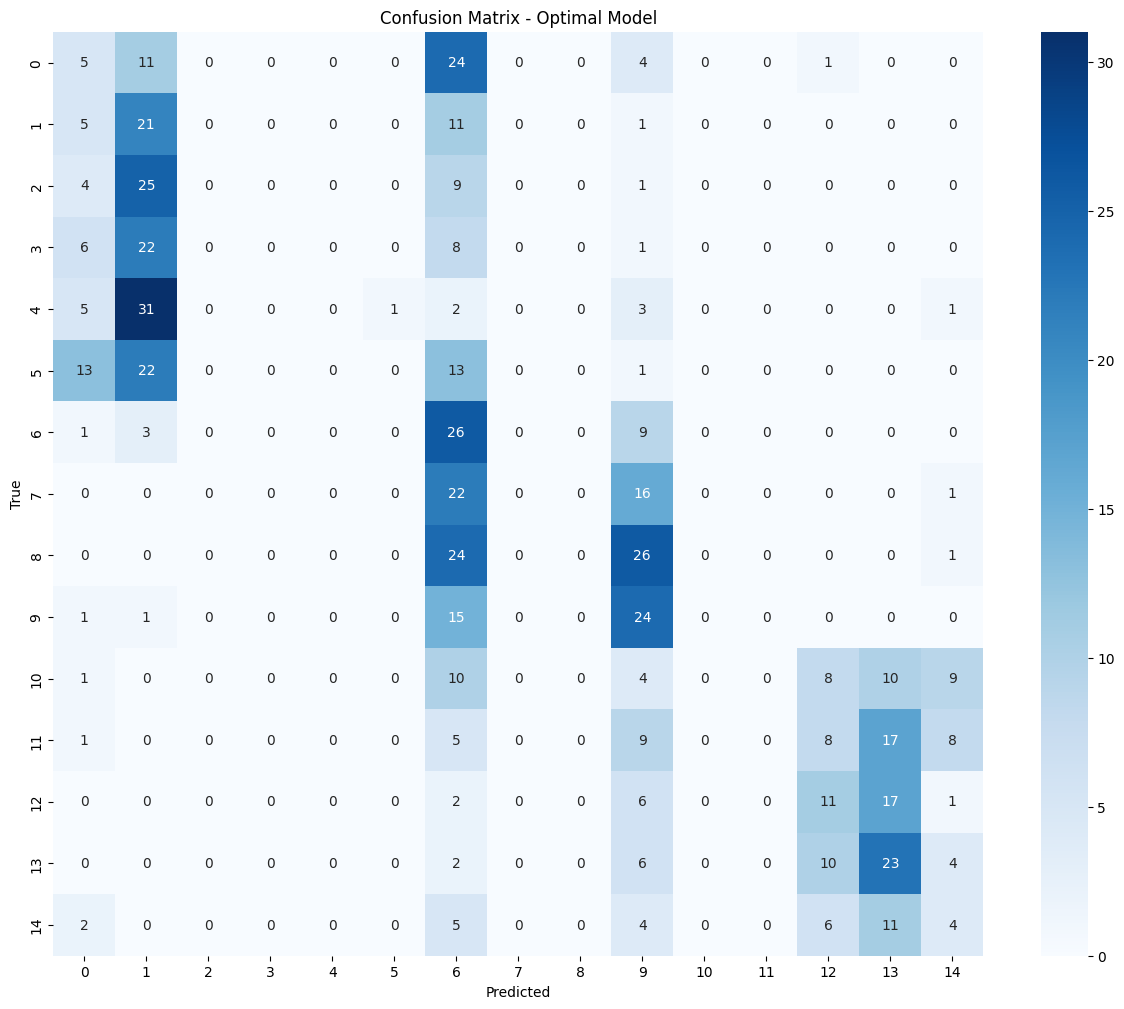

In [ ]:
# Define the confusion matrices and titles for plotting
confusion_matrices = [cm_1]
titles = ['Optimal Model']

# Generate the confusion matrix
cm_1 = confusion_matrix(pred_1_true, pred_1_labels)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(15, 12))  # Adjust figure size as needed
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(cm_1.shape[1])],
            yticklabels=[str(i) for i in range(cm_1.shape[0])])
plt.title('Confusion Matrix - Optimal Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print("Optimal Model")
print(classification_report(pred_1_true, pred_1_labels))

Optimal Model
              precision    recall  f1-score   support

           0       0.11      0.11      0.11        45
           1       0.15      0.55      0.24        38
           2       0.00      0.00      0.00        39
           3       0.00      0.00      0.00        37
           4       0.00      0.00      0.00        43
           5       0.00      0.00      0.00        49
           6       0.15      0.67      0.24        39
           7       0.00      0.00      0.00        39
           8       0.00      0.00      0.00        51
           9       0.21      0.59      0.31        41
          10       0.00      0.00      0.00        42
          11       0.00      0.00      0.00        48
          12       0.25      0.30      0.27        37
          13       0.29      0.51      0.37        45
          14       0.14      0.12      0.13        32

    accuracy                           0.18       625
   macro avg       0.09      0.19      0.11       625
weighted avg

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
